In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
from susse.estimators.validation.metrics import StatisticalMetrics

In [2]:
# Coordinates for Soroti, Uganda
latitude = 1.7157
longitude = 33.6117
tz = 'Africa/Kampala'

start = '2021-03-01'
end = '2021-03-31'

In [3]:
soroti = pvlib.location.Location(latitude, longitude, tz=tz)

In [4]:
def percentage_difference(measurement : pd.Series, prediction : pd.Series) -> pd.Series:
    return (prediction - measurement) / measurement * 100

In [5]:
def plot_ground_vs_estimate(ground : pd.Series, estimate : pd.Series):
    fig, ax = plt.subplots(2, 2, figsize=(13, 7))

    ground.plot(ax=ax[0, 0], color='blue')
    ax[0, 0].set_title('Ground Values')
    ax[0, 0].set_ylabel('GHI (kWh/m2/day)')

    estimate.plot(ax=ax[0, 1], color='orange')
    ax[0, 1].set_title('Estimate Values')
    ax[0, 1].set_ylabel('GHI (kWh/m2/day)')

    ground.plot(ax=ax[1, 0], color='blue')
    estimate.plot(ax=ax[1, 0], color='orange')
    ax[1, 0].set_title('Ground vs Estimate Values')
    ax[1, 0].set_ylabel('GHI (kWh/m2/day)')
    ax[1, 0].legend()

    diff = percentage_difference(ground, estimate)
    diff.plot(ax=ax[1, 1], color='green')
    ax[1, 1].set_title('Percentage Difference')
    ax[1, 1].set_ylabel('Percentage difference (%)')
    ax[1, 1].axhline(0, color='lightgray', lw=0.5)

    for ax in ax.flat:
        ax.set_xticks(ground.index[::2])
        ax.set_xticklabels(ground.index[::2].strftime('%d'))

    plt.tight_layout()
    plt.show()

# Ground data

In [6]:
Soroti_ground = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2021.csv')
Soroti_ground['Day'] = pd.to_datetime(Soroti_ground['Day'])
Soroti_ground = Soroti_ground.set_index('Day')

# getting data for March 2021
Soroti_ground = Soroti_ground.loc[start:end]
Soroti_ground.head()

,Temperature (C),Temperature (SAT) (C),Rain (mm),GHI_1 (kWh/m2/day),GHI_2 (kWh/m2/day),GHI_SAT (kWh/m2/day),GHI (1) vs (2) (%),GHI (1) vs (SAT) (%),DHI (1) (kWh/m2/day),DHI (SAT) (kWh/m2/day),DHI (1) vs (SAT) (%)
Day,,,,,,,,,,,
2021-03-01,28.11,27.05,0.0,6.90,6.92,7.17,-0.20,-3.84,1.56,1.76,-12.53
2021-03-02,29.07,26.95,0.0,7.41,7.43,7.41,-0.36,0.02,1.62,1.70,-5.03
2021-03-03,27.73,26.80,0.0,6.15,6.17,6.02,-0.37,2.16,2.86,3.14,-9.86
2021-03-04,25.09,26.43,0.8,4.78,4.81,4.38,-0.54,8.48,2.31,2.30,0.56
2021-03-05,26.67,26.44,1.4,6.44,6.46,7.12,-0.30,-10.53,2.02,2.07,-2.42


In [7]:
ghi_ground = Soroti_ground['GHI_1 (kWh/m2/day)']
ghi_solargis = Soroti_ground['GHI_SAT (kWh/m2/day)']
diff_solargis = Soroti_ground['GHI (1) vs (SAT) (%)']

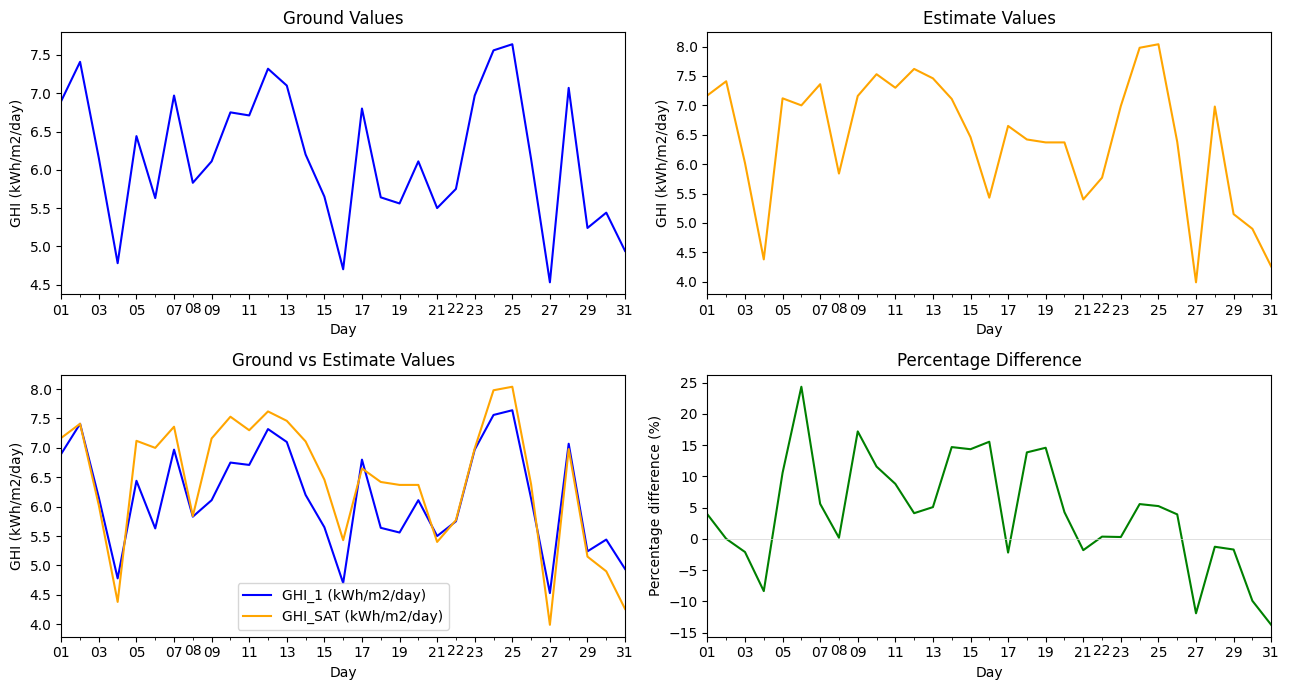

In [8]:
plot_ground_vs_estimate(ghi_ground, ghi_solargis)

# Clearsky radiation

In [24]:
# end = "2021-03-31 23:00"
times = pd.date_range(start=start, end="2021-03-31 23:00", freq='1h', tz='UTC')


In [25]:
times

DatetimeIndex(['2021-03-01 00:00:00+00:00', '2021-03-01 01:00:00+00:00',
               '2021-03-01 02:00:00+00:00', '2021-03-01 03:00:00+00:00',
               '2021-03-01 04:00:00+00:00', '2021-03-01 05:00:00+00:00',
               '2021-03-01 06:00:00+00:00', '2021-03-01 07:00:00+00:00',
               '2021-03-01 08:00:00+00:00', '2021-03-01 09:00:00+00:00',
               ...
               '2021-03-31 14:00:00+00:00', '2021-03-31 15:00:00+00:00',
               '2021-03-31 16:00:00+00:00', '2021-03-31 17:00:00+00:00',
               '2021-03-31 18:00:00+00:00', '2021-03-31 19:00:00+00:00',
               '2021-03-31 20:00:00+00:00', '2021-03-31 21:00:00+00:00',
               '2021-03-31 22:00:00+00:00', '2021-03-31 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=744, freq='h')

In [26]:
def convert_to_kwh_per_m2_per_day(ghi):
    ghi_daily = ghi.resample('D').sum()
    ghi_daily = ghi_daily / 1000
    ghi_daily.index = pd.to_datetime(ghi_daily.index.strftime('%Y-%m-%d'))
    return ghi_daily

### Ineichen

In [27]:
ineichen = soroti.get_clearsky(times)
ineichen.tail(20)

,ghi,dni,dhi
2021-03-31 04:00:00+00:00,6.687080,38.784364,4.730600
2021-03-31 05:00:00+00:00,239.137357,569.975886,65.989619
2021-03-31 06:00:00+00:00,520.913332,776.437542,102.314203
2021-03-31 07:00:00+00:00,766.569108,865.765634,127.526758
2021-03-31 08:00:00+00:00,952.048629,909.850738,144.981074
2021-03-31 09:00:00+00:00,1062.824971,930.443574,155.026091
2021-03-31 10:00:00+00:00,1090.722504,935.108253,157.523165
2021-03-31 11:00:00+00:00,1033.730686,925.367292,152.409421
2021-03-31 12:00:00+00:00,895.991882,897.973142,139.802217
2021-03-31 13:00:00+00:00,687.817616,842.014650,119.778137


In [28]:
ghi_in = convert_to_kwh_per_m2_per_day(ineichen['ghi'])

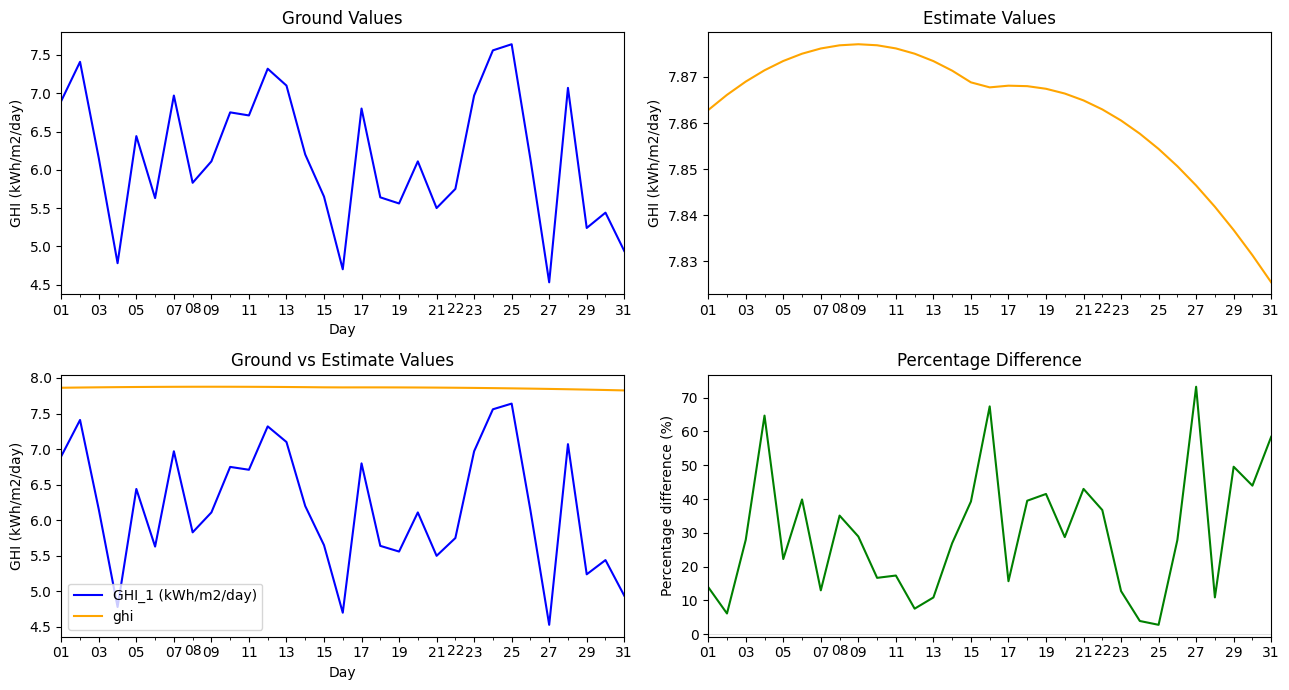

In [30]:
plot_ground_vs_estimate(ghi_ground, ghi_in)

### Simplified_Solis

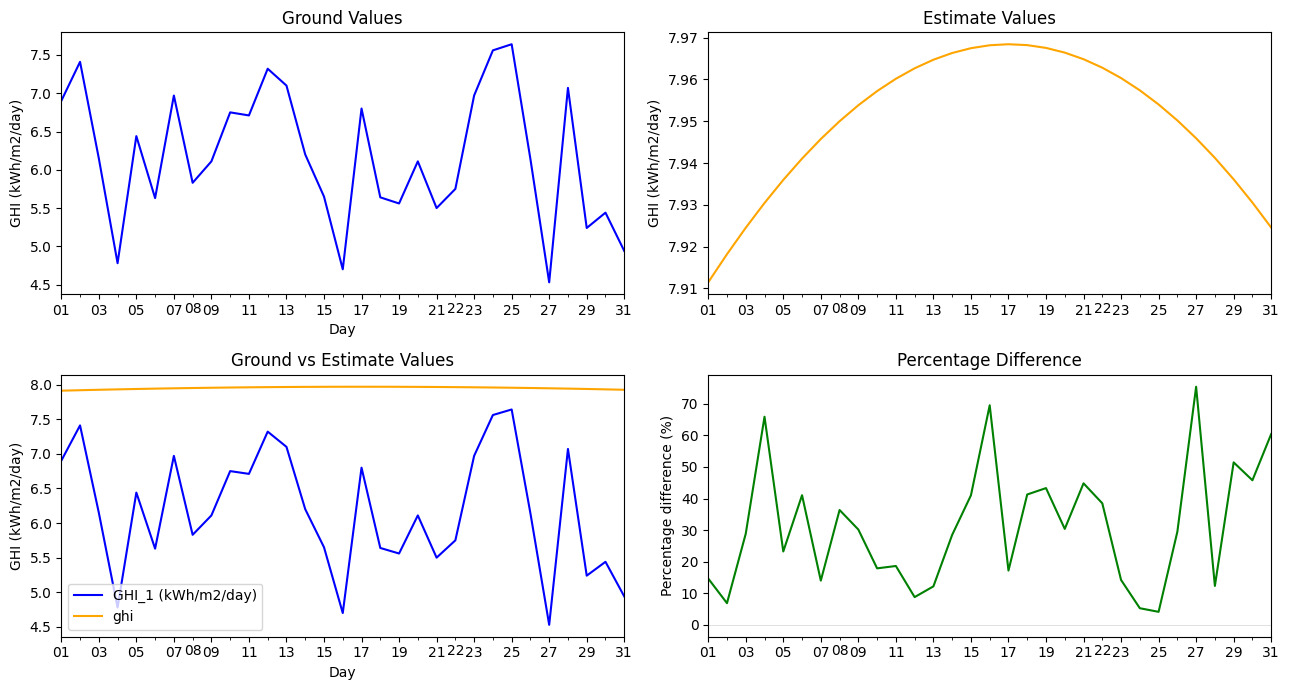

In [31]:
simplified_solis = soroti.get_clearsky(times, model='simplified_solis')
plot_ground_vs_estimate(ghi_ground, convert_to_kwh_per_m2_per_day(simplified_solis['ghi']))

### Haurwitz

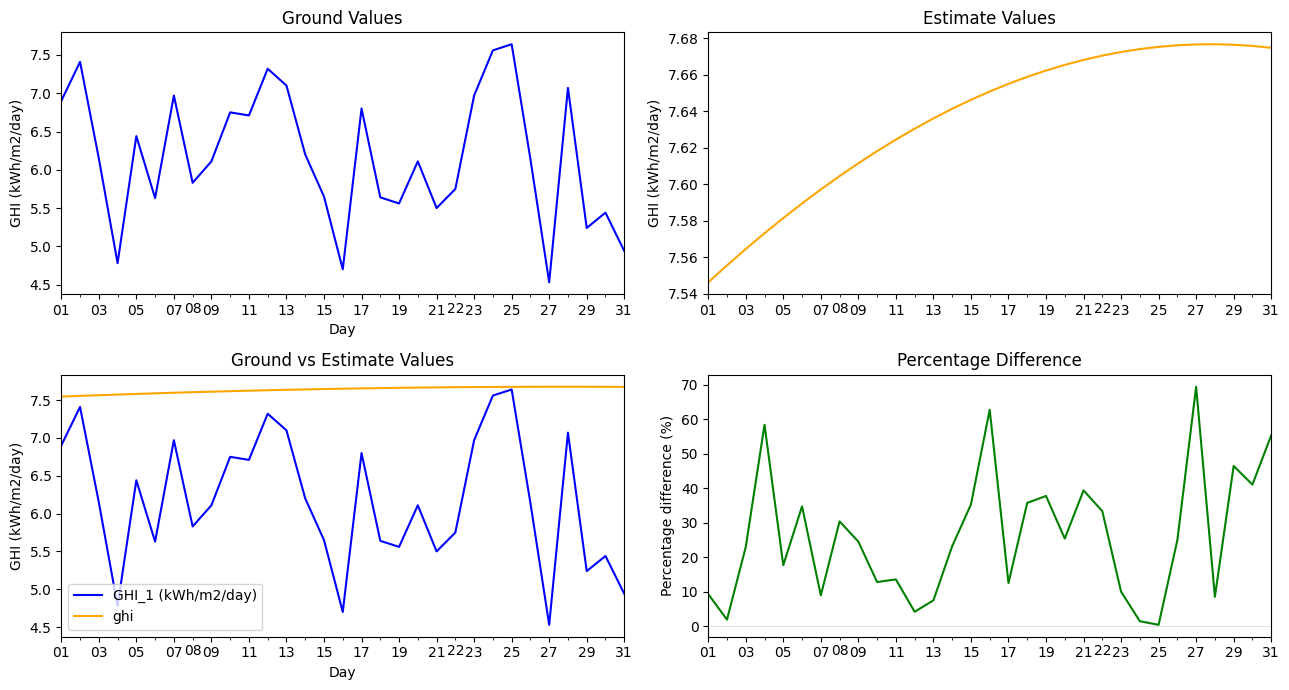

In [32]:
haurwitz = soroti.get_clearsky(times, model='haurwitz')
plot_ground_vs_estimate(ghi_ground, convert_to_kwh_per_m2_per_day(haurwitz['ghi']))

## REST2

In [33]:
df_params = soroti.get_solarposition(times)
df_params.head()

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2021-03-01 00:00:00+00:00,149.037903,149.037903,-59.037903,-59.037903,101.931676,-12.369237
2021-03-01 01:00:00+00:00,134.282973,134.282973,-44.282973,-44.282973,98.908575,-12.361138
2021-03-01 02:00:00+00:00,119.443160,119.443160,-29.443160,-29.443160,97.706563,-12.353025
2021-03-01 03:00:00+00:00,104.575784,104.575784,-14.575784,-14.575784,97.342850,-12.344897
2021-03-01 04:00:00+00:00,89.318444,89.705108,0.681556,0.294892,97.533990,-12.336755


In [37]:
pressure = pvlib.atmosphere.alt2pres(soroti.altitude)
pressure

88897.9583198836

# Diffuse

# NREL

In [38]:
from susse.api_clients.nrel import NRELDataFetcher

In [ ]:
import requests
import pandas as pd
import urllib.parse
import time

API_KEY = "{{YOUR_API_KEY}}"
EMAIL = "mukiibirogerz@gmail.com"
BASE_URL = "https://developer.nrel.gov/api/nsrdb/v2/solar/nsrdb-msg-v1-0-0-download.json?"
POINTS = [
'1817177'
]

def main():
    input_data = {
        'attributes': 'solar_zenith_angle,surface_albedo,total_precipitable_water,clearsky_dhi,clearsky_dni,clearsky_ghi,cloud_type,dew_point,relative_humidity,surface_pressure,dhi,dni,fill_flag,ghi,air_temperature,wind_direction,wind_speed',
        'interval': '60',
        'include_leap_day': 'true',
        
        'api_key': API_KEY,
        'email': EMAIL,
    }
    for name in ['2020','2021','2022']:
        print(f"Processing name: {name}")
        for id, location_ids in enumerate(POINTS):
            input_data['names'] = [name]
            input_data['location_ids'] = location_ids
            print(f'Making request for point group {id + 1} of {len(POINTS)}...')

            if '.csv' in BASE_URL:
                url = BASE_URL + urllib.parse.urlencode(data, True)
                # Note: CSV format is only supported for single point requests
                # Suggest that you might append to a larger data frame
                data = pd.read_csv(url)
                print(f'Response data (you should replace this print statement with your processing): {data}')
                # You can use the following code to write it to a file
                # data.to_csv('SingleBigDataPoint.csv')
            else:
                headers = {
                  'x-api-key': API_KEY
                }
                data = get_response_json_and_handle_errors(requests.post(BASE_URL, input_data, headers=headers))
                download_url = data['outputs']['downloadUrl']
                # You can do with what you will the download url
                print(data['outputs']['message'])
                print(f"Data can be downloaded from this url when ready: {download_url}")

                # Delay for 1 second to prevent rate limiting
                time.sleep(1)
            print(f'Processed')


def get_response_json_and_handle_errors(response: requests.Response) -> dict:
    """Takes the given response and handles any errors, along with providing
    the resulting json

    Parameters
    ----------
    response : requests.Response
        The response object

    Returns
    -------
    dict
        The resulting json
    """
    if response.status_code != 200:
        print(f"An error has occurred with the server or the request. The request response code/status: {response.status_code} {response.reason}")
        print(f"The response body: {response.text}")
        exit(1)

    try:
        response_json = response.json()
    except:
        print(f"The response couldn't be parsed as JSON, likely an issue with the server, here is the text: {response.text}")
        exit(1)

    if len(response_json['errors']) > 0:
        errors = '\n'.join(response_json['errors'])
        print(f"The request errored out, here are the errors: {errors}")
        exit(1)
    return response_json

if __name__ == "__main__":
    main()